# Categorías de ICEE y comparación de variables

Este cuaderno parte de `datos/Municipio con ICEE menor a 95 por ciento.csv`, pero no lo modifica. La primera celda crea `datos/copia Municipio con ICEE menor a 95 por ciento.csv` y todo el análisis lee solo esa copia.

Las áreas no municipalizadas, las filas con `ANM` igual a 1, quedan fuera del análisis.

Cada municipio queda en una categoría según su ICEE:

| Categoría | Regla |
| --- | --- |
| categoria 1 | 0 ≤ ICEE < 25 |
| categoria 2 | 25 ≤ ICEE < 50 |
| categoria 3 | 50 ≤ ICEE < 75 |
| categoria 4 | ICEE ≥ 75 |

La comparación usa NBI, ICEE, la categoría administrativa, PDET, ZOMAC, las tres series de VSS, mdm, población, valor agregado percapita y actividades terciarias. `valor agregado percapita` es el valor agregado dividido por la población. Hay una gráfica por variable.


In [1]:
from pathlib import Path
import csv
import shutil

import matplotlib.pyplot as plt
import pandas as pd

ORIGINAL = Path("datos") / "Municipio con ICEE menor a 95 por ciento.csv"
COPIA = Path("datos") / "copia Municipio con ICEE menor a 95 por ciento.csv"
shutil.copyfile(ORIGINAL, COPIA)

def banda_icee(texto):
    valor = float(str(texto).strip().replace(".", "").replace(",", "."))
    if valor < 25:
        return "categoria 1"
    if valor < 50:
        return "categoria 2"
    if valor < 75:
        return "categoria 3"
    return "categoria 4"

with COPIA.open(encoding="utf-8", newline="") as archivo:
    lector = csv.DictReader(archivo, delimiter=";")
    filas = list(lector)
    campos = list(lector.fieldnames)

campos = [campo for campo in campos if campo != "categoria ICEE"] + ["categoria ICEE"]
for fila in filas:
    fila["categoria ICEE"] = banda_icee(fila["ICEE"])

with COPIA.open("w", encoding="utf-8", newline="") as archivo:
    escritor = csv.DictWriter(archivo, fieldnames=campos, delimiter=";", lineterminator="\r\n")
    escritor.writeheader()
    escritor.writerows(filas)

df = pd.read_csv(COPIA, sep=";", decimal=",", encoding="utf-8")
ORDEN = ["categoria 1", "categoria 2", "categoria 3", "categoria 4"]
RANGOS = {
    "categoria 1": "0 ≤ ICEE < 25",
    "categoria 2": "25 ≤ ICEE < 50",
    "categoria 3": "50 ≤ ICEE < 75",
    "categoria 4": "ICEE ≥ 75",
}
COLORES = {
    "categoria 1": "#9F1239",
    "categoria 2": "#EA580C",
    "categoria 3": "#CA8A04",
    "categoria 4": "#0F766E",
}
df["categoria ICEE"] = pd.Categorical(df["categoria ICEE"], categories=ORDEN, ordered=True)

excluidos = int((df["ANM"] == 1).sum())
df = df.loc[df["ANM"] != 1].copy()
df["valor agregado percapita"] = df["valor agregado"] / df["POBLACION"]
print(f"Original intacto en su ruta. Copia de trabajo: {COPIA}")
print(f"Se excluyen {excluidos} áreas no municipalizadas. El análisis usa {len(df)} municipios.")
conteo = df["categoria ICEE"].value_counts().reindex(ORDEN)
display(conteo.to_frame("municipios"))


Original intacto en su ruta. Copia de trabajo: datos/copia Municipio con ICEE menor a 95 por ciento.csv
Se excluyen 19 áreas no municipalizadas. El análisis usa 725 municipios.


,municipios
categoria ICEE,
categoria 1,16
categoria 2,22
categoria 3,212
categoria 4,475


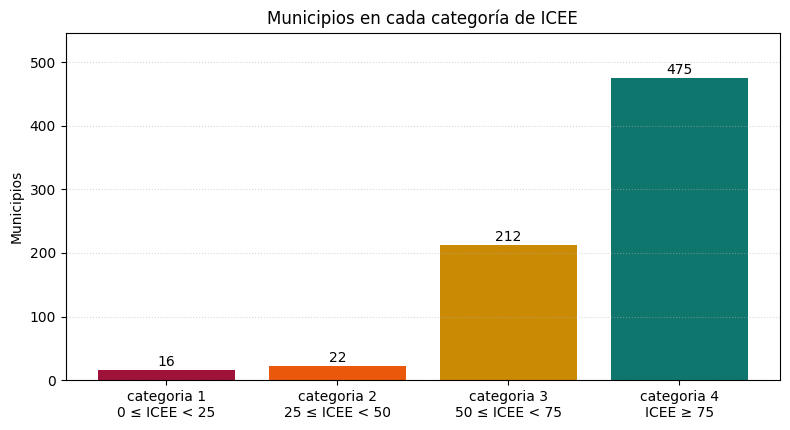

In [2]:
fig, ax = plt.subplots(figsize=(8, 4.4))
conteo = df["categoria ICEE"].value_counts().reindex(ORDEN)
barras = ax.bar(range(len(ORDEN)), conteo, color=[COLORES[cat] for cat in ORDEN])
ax.set_xticks(range(len(ORDEN)), [f"{cat}\n{RANGOS[cat]}" for cat in ORDEN])
ax.set_ylabel("Municipios")
ax.set_title("Municipios en cada categoría de ICEE")
for barra, valor in zip(barras, conteo):
    ax.text(barra.get_x() + barra.get_width() / 2, valor + 6, str(int(valor)), ha="center")
ax.set_ylim(0, conteo.max() * 1.15)
ax.grid(axis="y", linestyle=":", alpha=0.5)
fig.tight_layout()
plt.show()


## Cómo leer las gráficas

En las variables numéricas, cada caja muestra la mitad central de los municipios de esa categoría. La línea de la caja es la mediana. Los puntos sueltos son municipios muy alejados del resto.

VSS, población y actividades terciarias tienen municipios mucho más grandes que el resto. Esas gráficas usan una escala simétrica logarítmica para que las cuatro categorías se puedan comparar. NBI, ICEE, mdm y el valor agregado percapita van en escala lineal.

En PDET y ZOMAC la barra es el porcentaje de municipios con valor 1 dentro de la categoría. En la categoría administrativa, cada barra parte de 100% y muestra cómo se reparte esa categoría de ICEE.


In [3]:
def grafico_caja(columna, titulo, logaritmica=False):
    fig, ax = plt.subplots(figsize=(8.4, 4.8))
    series = []
    etiquetas = []
    for cat in ORDEN:
        serie = df.loc[df["categoria ICEE"] == cat, columna].dropna()
        series.append(serie)
        etiquetas.append(f"{cat}\n{RANGOS[cat]}\nn={len(serie)}")
    cajas = ax.boxplot(series, tick_labels=etiquetas, patch_artist=True, showfliers=True)
    for caja, cat in zip(cajas["boxes"], ORDEN):
        caja.set_facecolor(COLORES[cat])
        caja.set_alpha(0.8)
    if logaritmica:
        ax.set_yscale("symlog", linthresh=1)
        ax.set_ylabel(f"{columna} (escala simétrica logarítmica)")
    else:
        ax.set_ylabel(columna)
    ax.set_title(titulo)
    ax.grid(axis="y", linestyle=":", alpha=0.5)
    fig.tight_layout()
    plt.show()
    mediana = df.groupby("categoria ICEE", observed=True)[columna].median()
    print("Mediana")
    print(mediana.round(2).to_string())

def grafico_porcentaje(columna, titulo):
    fig, ax = plt.subplots(figsize=(8.4, 4.6))
    porcentajes = [(df.loc[df["categoria ICEE"] == cat, columna].mean() * 100) for cat in ORDEN]
    barras = ax.bar(range(len(ORDEN)), porcentajes, color=[COLORES[cat] for cat in ORDEN])
    ax.set_xticks(range(len(ORDEN)), [f"{cat}\n{RANGOS[cat]}" for cat in ORDEN])
    ax.set_ylim(0, 100)
    ax.set_ylabel("Porcentaje de municipios")
    ax.set_title(titulo)
    for barra, valor in zip(barras, porcentajes):
        ax.text(
            barra.get_x() + barra.get_width() / 2,
            valor + 2,
            f"{valor:.1f}%".replace(".", ","),
            ha="center",
        )
    ax.grid(axis="y", linestyle=":", alpha=0.5)
    fig.tight_layout()
    plt.show()


### NBI


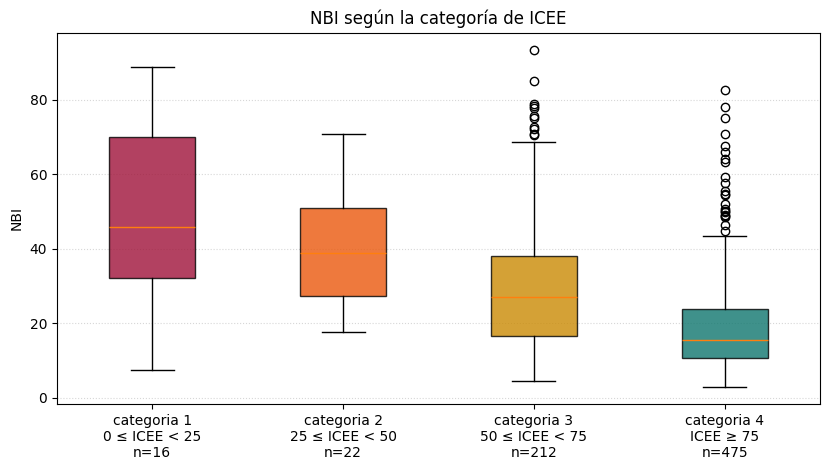

Mediana
categoria ICEE
categoria 1    45.97
categoria 2    38.90
categoria 3    27.17
categoria 4    15.49


In [4]:
grafico_caja("NBI", "NBI según la categoría de ICEE", logaritmica=False)


### ICEE


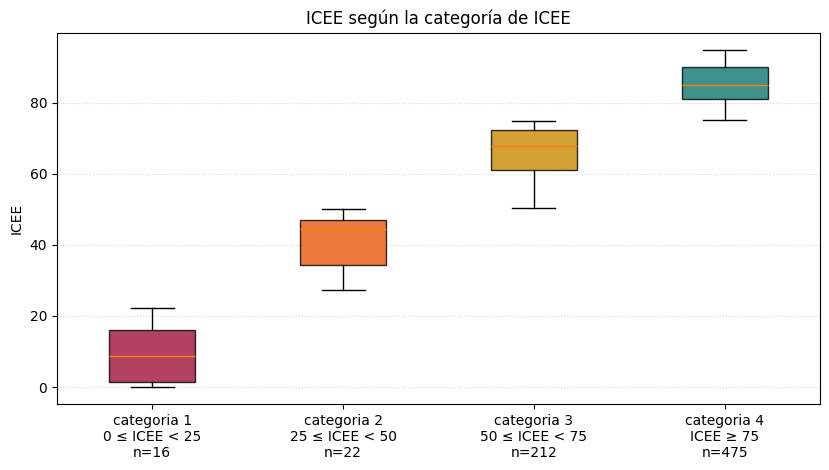

Mediana
categoria ICEE
categoria 1     8.74
categoria 2    44.45
categoria 3    67.80
categoria 4    84.95


In [5]:
grafico_caja("ICEE", "ICEE según la categoría de ICEE", logaritmica=False)


### VSS Urbano


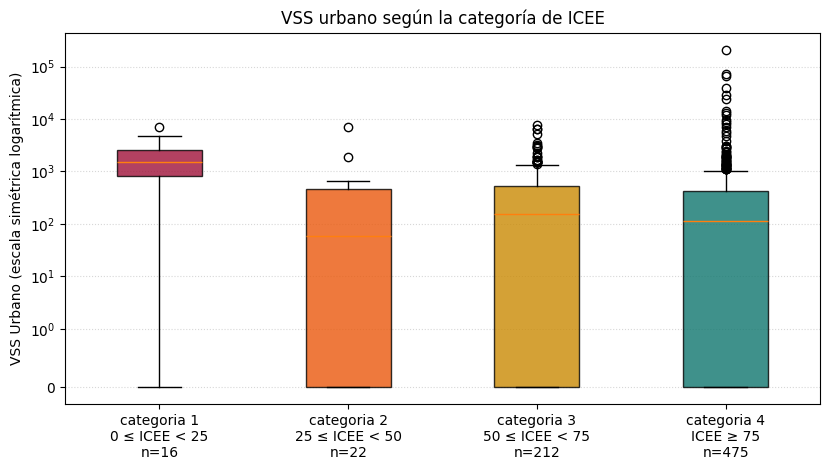

Mediana
categoria ICEE
categoria 1    1486.0
categoria 2      58.0
categoria 3     152.5
categoria 4     114.0


In [6]:
grafico_caja("VSS Urbano", "VSS urbano según la categoría de ICEE", logaritmica=True)


### VSS Rural


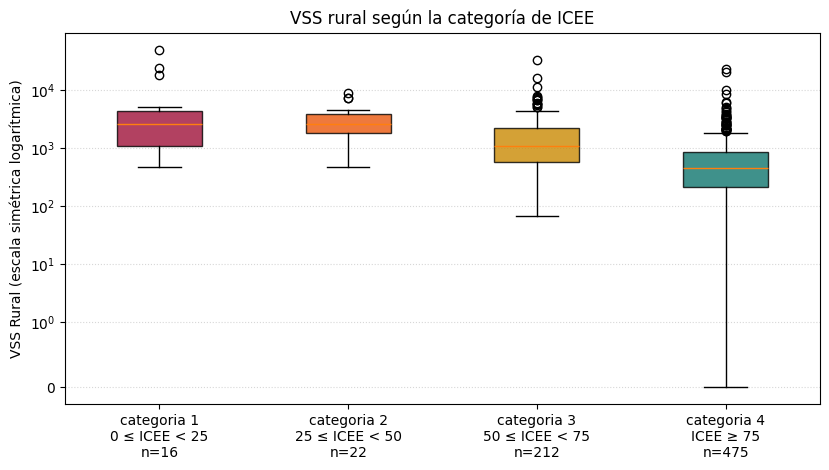

Mediana
categoria ICEE
categoria 1    2568.0
categoria 2    2612.5
categoria 3    1092.5
categoria 4     458.0


In [7]:
grafico_caja("VSS Rural", "VSS rural según la categoría de ICEE", logaritmica=True)


### VSS Total


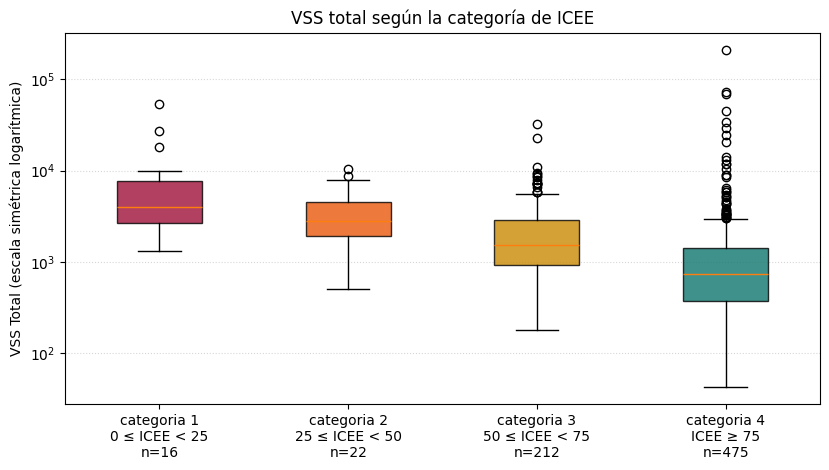

Mediana
categoria ICEE
categoria 1    4024.0
categoria 2    2837.0
categoria 3    1526.5
categoria 4     734.0


In [8]:
grafico_caja("VSS Total", "VSS total según la categoría de ICEE", logaritmica=True)


### mdm


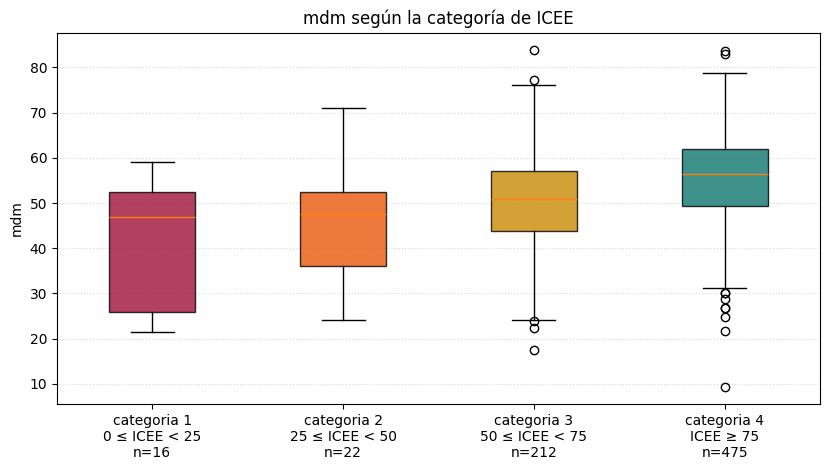

Mediana
categoria ICEE
categoria 1    46.82
categoria 2    47.52
categoria 3    50.88
categoria 4    56.35


In [9]:
grafico_caja("mdm", "mdm según la categoría de ICEE", logaritmica=False)


### POBLACION


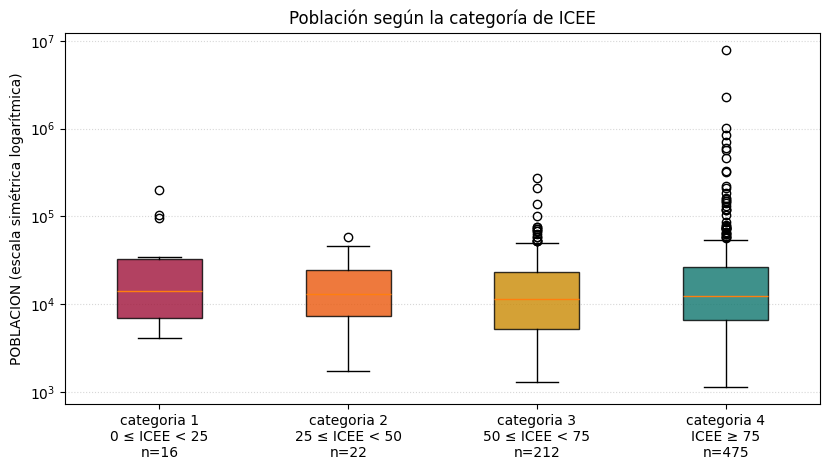

Mediana
categoria ICEE
categoria 1    14276.0
categoria 2    13202.5
categoria 3    11473.5
categoria 4    12309.0


In [10]:
grafico_caja("POBLACION", "Población según la categoría de ICEE", logaritmica=True)


### valor agregado percapita


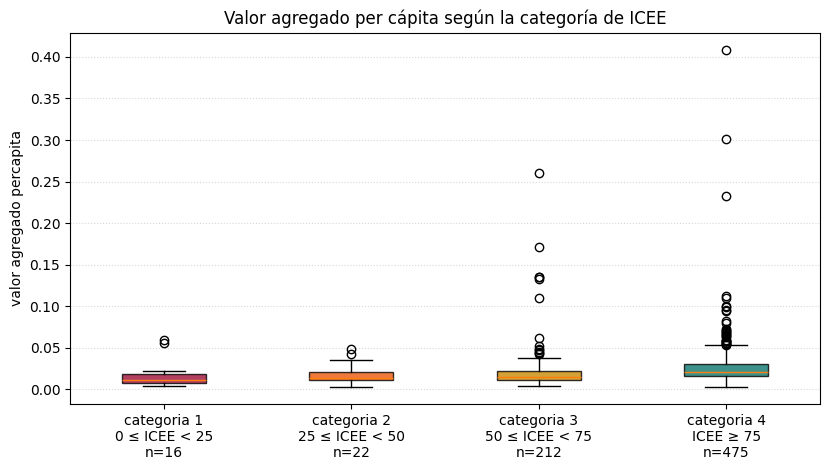

Mediana
categoria ICEE
categoria 1    0.01
categoria 2    0.01
categoria 3    0.02
categoria 4    0.02


In [11]:
grafico_caja("valor agregado percapita", "Valor agregado per cápita según la categoría de ICEE", logaritmica=False)


### Actividades terciarias


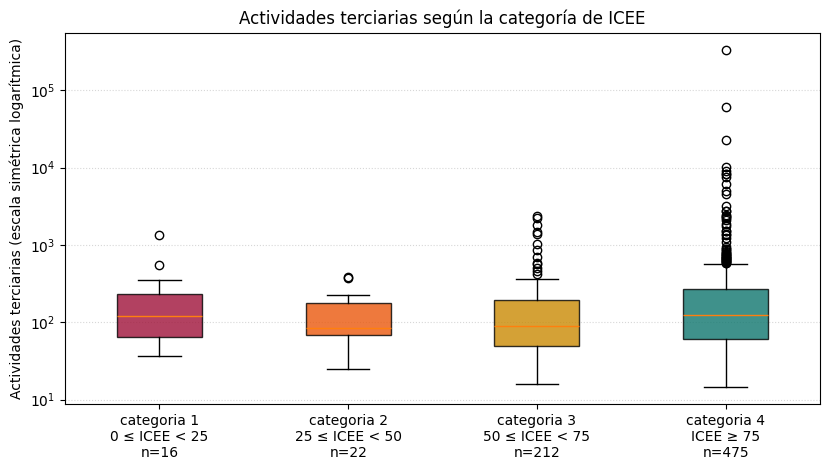

Mediana
categoria ICEE
categoria 1    119.31
categoria 2     85.47
categoria 3     90.29
categoria 4    122.44


In [12]:
grafico_caja("Actividades terciarias", "Actividades terciarias según la categoría de ICEE", logaritmica=True)


### PDET y ZOMAC

Estas columnas valen 1 o 0. La gráfica muestra el porcentaje de municipios en 1 dentro de cada categoría de ICEE.


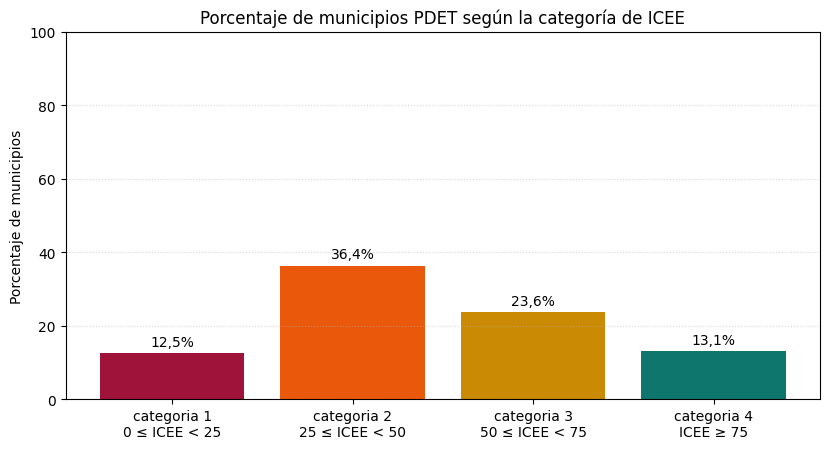

In [13]:
grafico_porcentaje("PDET", "Porcentaje de municipios PDET según la categoría de ICEE")


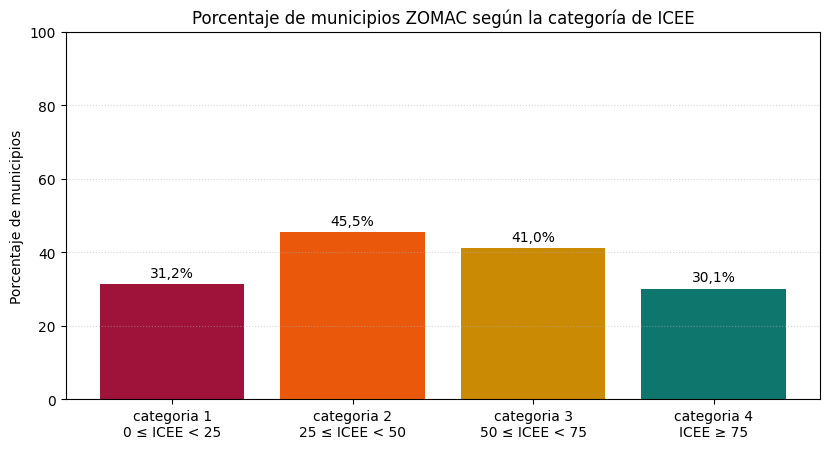

In [14]:
grafico_porcentaje("ZOMAC", "Porcentaje de municipios ZOMAC según la categoría de ICEE")


### Categoría administrativa

`CATEGORIA` es la categoría del municipio (1 a 6 o ESP), distinta de la categoría de ICEE definida arriba. La gráfica muestra la composición de cada categoría de ICEE, en porcentaje.


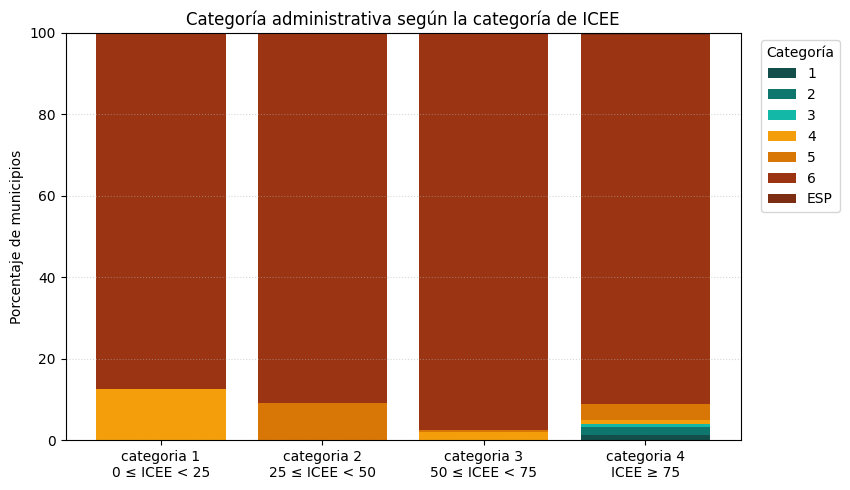

CATEGORIA,1,2,3,4,5,6,ESP
categoria ICEE,,,,,,,
categoria 1,0,0,0,2,0,14,0
categoria 2,0,0,0,0,2,20,0
categoria 3,0,0,0,4,1,207,0
categoria 4,6,9,4,5,18,430,3


In [15]:
orden_admin = ["1", "2", "3", "4", "5", "6", "ESP"]
colores_admin = ["#134E4A", "#0F766E", "#14B8A6", "#F59E0B", "#D97706", "#9A3412", "#7C2D12"]
administrativa = df["CATEGORIA"].astype(str)
tabla = pd.crosstab(df["categoria ICEE"], administrativa).reindex(index=ORDEN, columns=orden_admin, fill_value=0)
porcentaje = tabla.div(tabla.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(8.6, 5))
acumulado = [0] * len(ORDEN)
for nivel, color in zip(orden_admin, colores_admin):
    valores = porcentaje[nivel].tolist()
    ax.bar(range(len(ORDEN)), valores, bottom=acumulado, color=color, label=nivel)
    acumulado = [base + valor for base, valor in zip(acumulado, valores)]
ax.set_xticks(range(len(ORDEN)), [f"{cat}\n{RANGOS[cat]}" for cat in ORDEN])
ax.set_ylabel("Porcentaje de municipios")
ax.set_ylim(0, 100)
ax.set_title("Categoría administrativa según la categoría de ICEE")
ax.legend(title="Categoría", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", linestyle=":", alpha=0.5)
fig.tight_layout()
plt.show()
display(tabla)


## Lectura

Quedan 725 municipios. Se excluyen las 19 áreas no municipalizadas. De los 725, 16 están en la categoria 1, 22 en la categoria 2, 212 en la categoria 3 y 475 en la categoria 4.

A medida que sube la categoría de ICEE, el NBI baja y el mdm sube. La mediana de NBI pasa de 45,97 en la categoria 1 a 15,49 en la categoria 4. La mediana de mdm pasa de 46,82 a 56,35. El ICEE de cada caja coincide con el corte de su categoría: la mediana va de 8,74 a 84,95.

El déficit de viviendas es más alto en la categoria 1. La mediana de VSS total es 4.024 ahí, 2.837 en la categoria 2, 1.526,50 en la categoria 3 y 734 en la categoria 4. VSS urbano también tiene su mediana más alta en la categoria 1 (1.486). VSS rural es parecido en las dos primeras categorías (2.568 y 2.612,50) y baja hasta 458 en la categoria 4.

La población no crece de corrido con el ICEE. Su mediana es 14.276 en la categoria 1, baja a 11.474 en la categoria 3 y queda en 12.309 en la categoria 4. El valor agregado por habitante sí sube: la mediana pasa de 0,0119 en la categoria 1 a 0,0137 en la 2, 0,0154 en la 3 y 0,0206 en la 4. Las actividades terciarias tienen mediana 119,31 en la categoria 1, cerca de 85 a 90 en las categorías 2 y 3, y 122,44 en la categoria 4. Las ciudades grandes siguen en la categoria 4 y estiran la parte alta de esas cajas.

PDET es más frecuente en la categoria 2 (36,4%) que en la categoria 1 (12,5%) y que en la categoria 4 (13,1%). ZOMAC también es más frecuente en la categoria 2 (45,5%) y en la categoria 3 (41,0%) que en la categoria 4 (30,1%).

Las categorías administrativas 1, 2, 3 y ESP aparecen solo en la categoria 4. La categoría 6 es la mayoría en las cuatro bandas: 14 de 16 en la categoria 1 y 430 de 475 en la categoria 4.
